# 1. Imports and Setup

In [19]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


# 2. Fetching Solana Market Data

In [20]:
sol = yf.Ticker("SOL-USD")
sol = sol.history(period="max")
sol.head()

,Open,High,Low,Close,Volume,Dividends,Stock Splits
Date,,,,,,,
2020-04-10 00:00:00+00:00,0.832005,1.313487,0.694187,0.951054,87364276,0.0,0.0
2020-04-11 00:00:00+00:00,0.951054,1.049073,0.765020,0.776819,43862444,0.0,0.0
2020-04-12 00:00:00+00:00,0.785448,0.956670,0.762426,0.882507,38736897,0.0,0.0
2020-04-13 00:00:00+00:00,0.890760,0.891603,0.773976,0.777832,18211285,0.0,0.0
2020-04-14 00:00:00+00:00,0.777832,0.796472,0.628169,0.661925,16747614,0.0,0.0


# 3. History Plot

<Axes: xlabel='Date'>

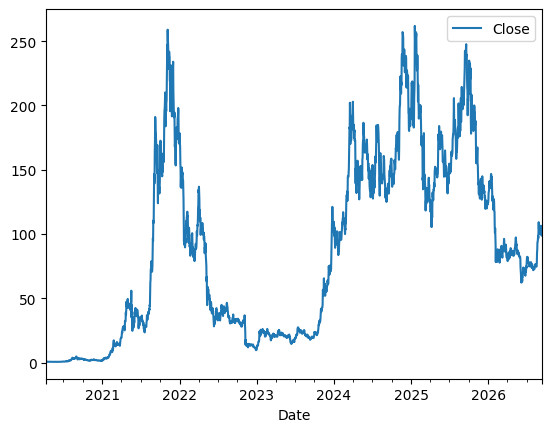

In [21]:
del sol['Dividends']
del sol['Stock Splits']
sol.plot.line(y="Close", use_index=True)

# 4. Creating a Target Variable

In [22]:
sol['Tomorrow'] = sol['Close'].shift(-1)
sol['Target'] = (sol['Tomorrow'] > sol['Close']).astype(int) 
sol

,Open,High,Low,Close,Volume,Tomorrow,Target
Date,,,,,,,
2020-04-10 00:00:00+00:00,0.832005,1.313487,0.694187,0.951054,87364276,0.776819,0
2020-04-11 00:00:00+00:00,0.951054,1.049073,0.765020,0.776819,43862444,0.882507,1
2020-04-12 00:00:00+00:00,0.785448,0.956670,0.762426,0.882507,38736897,0.777832,0
2020-04-13 00:00:00+00:00,0.890760,0.891603,0.773976,0.777832,18211285,0.661925,0
2020-04-14 00:00:00+00:00,0.777832,0.796472,0.628169,0.661925,16747614,0.646651,0
...,...,...,...,...,...,...,...
2026-09-08 00:00:00+00:00,103.866188,104.650146,101.849625,103.325127,2815722796,101.608063,0
2026-09-09 00:00:00+00:00,103.324905,104.983932,100.690605,101.608063,2975874780,98.689911,0
2026-09-10 00:00:00+00:00,101.608139,102.101334,98.689911,98.689911,2724393615,102.396248,1


# 5. Class Balance

In [23]:
print(sol['Target'].value_counts())
print(sol['Target'].value_counts(normalize=True))

Target
0    1184
1    1163
Name: count, dtype: int64
Target
0    0.504474
1    0.495526
Name: proportion, dtype: float64


# 6. Persistence Baseline

In [24]:
from sklearn.metrics import accuracy_score
train = sol.iloc[:-100]
test = sol.iloc[-100:]
persistance_preds = test['Target'].shift(1).fillna(0).astype(int)
persistance_score = accuracy_score(test['Target'], persistance_preds)
print("Perisistance accuracy :", persistance_score)

Perisistance accuracy : 0.5


# 7. Majority Baseline

In [25]:
majority = test['Target'].mode()[0]
majority_preds = [majority] * len(test)
majority_score = accuracy_score(test['Target'], majority_preds)
print("Majority accuracy:", majority_score)

Majority accuracy: 0.52


# 8. Feature Engineering

In [26]:
sol['Return'] = sol['Close'].pct_change() #daily return
sol['SMA_5'] = sol['Close'].rolling(window=5).mean() #5 days rolling average
#RSI
delta = sol['Close'].diff()
gain = delta.where(delta > 0, 0)
loss = -delta.where(delta < 0, 0)
avg_gain = gain.rolling(window=14).mean()
avg_loss = loss.rolling(window=14).mean()
rs = avg_gain/avg_loss
sol['RSI'] = 100 - (100/(1 + rs))

sol = sol.dropna()
print(sol[['Close','Return','SMA_5','RSI','Target']].head(20))


                              Close    Return     SMA_5        RSI  Target
Date                                                                      
2020-04-23 00:00:00+00:00  0.627457 -0.092747  0.610500  33.313156       1
2020-04-24 00:00:00+00:00  0.634242  0.010813  0.615954  33.776560       1
2020-04-25 00:00:00+00:00  0.643329  0.014327  0.636858  41.772616       0
2020-04-26 00:00:00+00:00  0.635506 -0.012160  0.646427  32.688194       0
2020-04-27 00:00:00+00:00  0.572372 -0.099344  0.622581  34.709341       1
2020-04-28 00:00:00+00:00  0.661293  0.155355  0.629348  49.950998       1
2020-04-29 00:00:00+00:00  0.745840  0.127851  0.651668  56.944694       0
2020-04-30 00:00:00+00:00  0.691045 -0.073468  0.661211  50.015798       1
2020-05-01 00:00:00+00:00  0.728794  0.054626  0.679869  54.646613       0
2020-05-02 00:00:00+00:00  0.715876 -0.017725  0.708570  52.398698       0
2020-05-03 00:00:00+00:00  0.679535 -0.050764  0.712218  55.279906       0
2020-05-04 00:00:00+00:00

# 9. Training Model

In [30]:
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score
from sklearn.ensemble import RandomForestClassifier

engineered = ['Return','SMA_5','RSI']
preds = ['Open','High','Low','Close','Volume']
scaler = StandardScaler()

train = sol.iloc[:-100]
test = sol.iloc[-100:]
X_train_eng = scaler.fit_transform(train[engineered])
X_test_eng = scaler.fit_transform(test[engineered])
X_train_raw = scaler.fit_transform(train[preds])
X_test_raw = scaler.transform(test[preds])
y_train = train['Target']
y_test = test['Target']

#engineered model
eng_model = RandomForestClassifier(n_estimators=100, min_samples_leaf=50, random_state=42)
eng_model.fit(X_train_eng, y_train)
eng_preds = eng_model.predict(X_test_eng)
eng_accuracy = accuracy_score(y_test, eng_preds)

#raw model
raw_model = RandomForestClassifier(n_estimators=100, min_samples_leaf=50, random_state=42)
raw_model.fit(X_train_raw, y_train)
raw_preds = raw_model.predict(X_test_raw)
raw_accuracy = accuracy_score(y_test, raw_preds)

print("Persistence Model :",persistance_score)
print("Majority Model :", majority_score)
print(f"Raw Feature Model:     {raw_accuracy:.4f}")
print(f"Engineered Model:      {eng_accuracy:.4f}")

Persistence Model : 0.5
Majority Model : 0.52
Raw Feature Model:     0.4900
Engineered Model:      0.4500


# 10. Feature Analysis

In [31]:
# Check if test set has enough variation
print(y_test.value_counts())

# Check feature importance
print(pd.DataFrame({
    'feature': engineered,
    'importance': eng_model.feature_importances_
}).sort_values('importance', ascending=False))

Target
1    52
0    48
Name: count, dtype: int64
  feature  importance
1   SMA_5    0.342606
2     RSI    0.330471
0  Return    0.326924


# 11. Actual vs Predicted Plot

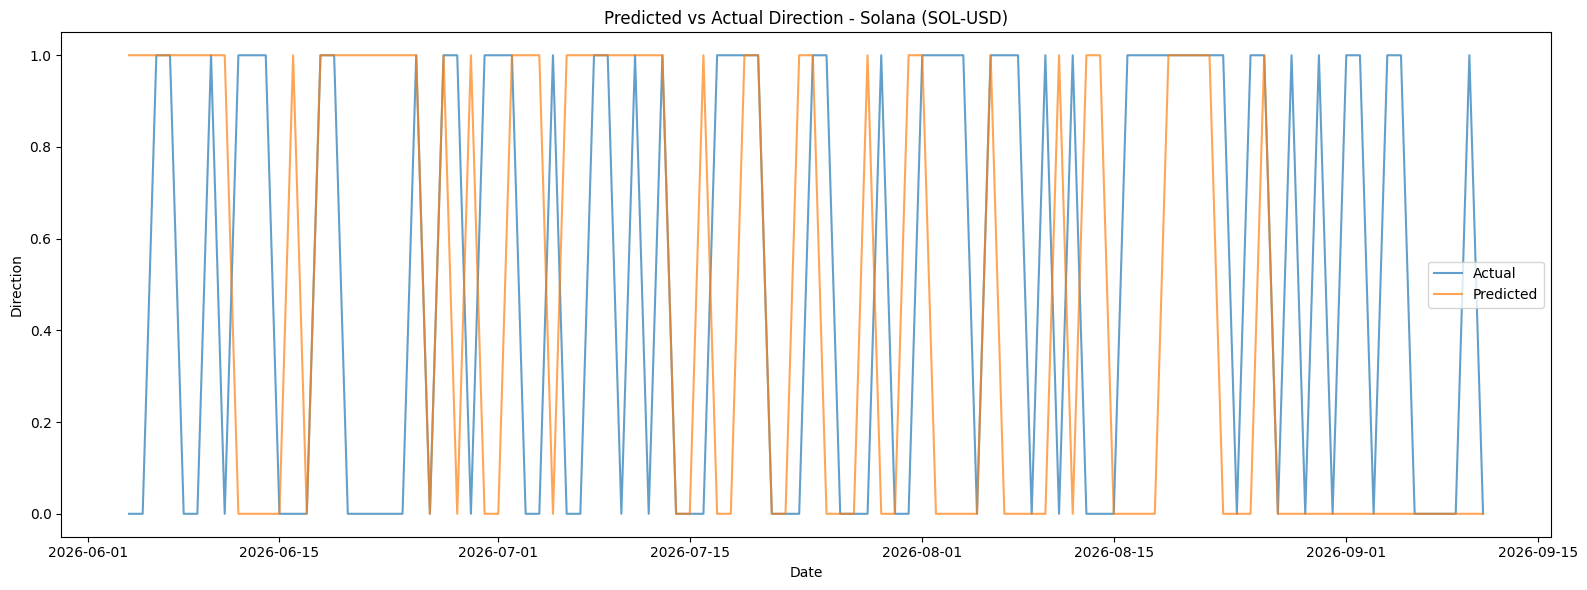

In [32]:
plt.figure(figsize=(16, 6))
plt.plot(test.index, y_test.values, label='Actual', alpha=0.7)
plt.plot(test.index, eng_preds, label='Predicted', alpha=0.7)
plt.title('Predicted vs Actual Direction - Solana (SOL-USD)')
plt.xlabel('Date')
plt.ylabel('Direction')
plt.legend()
plt.tight_layout()
plt.show()

# 12. Final Comparison

In [33]:
comparison = pd.DataFrame({
    'Model': ['Persistence Baseline', 'Majority Class Baseline', 'Raw Feature Model', 'Engineered Feature Model'],
    'Accuracy': [0.5, 0.52, 0.49, 0.45],
    'Beats Baseline': ['N/A', 'N/A', 'No', 'No']
})

print(comparison.to_string(index=False))


                   Model  Accuracy Beats Baseline
    Persistence Baseline      0.50            N/A
 Majority Class Baseline      0.52            N/A
       Raw Feature Model      0.49             No
Engineered Feature Model      0.45             No
